# Delivery ETA Optimization

Graph-based analysis of Delhivery's logistics network.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/delivery_data.csv")

print("Shape:", df.shape)

df.head()

Shape: (144867, 24)


,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


## Dataset Overview

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144867 entries, 0 to 144866
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   data                            144867 non-null  str    
 1   trip_creation_time              144867 non-null  str    
 2   route_schedule_uuid             144867 non-null  str    
 3   route_type                      144867 non-null  str    
 4   trip_uuid                       144867 non-null  str    
 5   source_center                   144867 non-null  str    
 6   source_name                     144574 non-null  str    
 7   destination_center              144867 non-null  str    
 8   destination_name                144606 non-null  str    
 9   od_start_time                   144867 non-null  str    
 10  od_end_time                     144867 non-null  str    
 11  start_scan_to_end_scan          144867 non-null  float64
 12  is_cutoff                  

## Missing Values

In [21]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

source_name         293
destination_name    261
dtype: int64

## Train-Test Distribution

In [22]:
df["data"].value_counts()

data
training    104858
test         40009
Name: count, dtype: int64

## Route Types

In [23]:
df["route_type"].value_counts()

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

## Network Scale

In [24]:
print("Unique Trips:", df["trip_uuid"].nunique())
print("Unique Sources:", df["source_center"].nunique())
print("Unique Destinations:", df["destination_center"].nunique())

Unique Trips: 14817
Unique Sources: 1508
Unique Destinations: 1481


## Transit Time Distribution

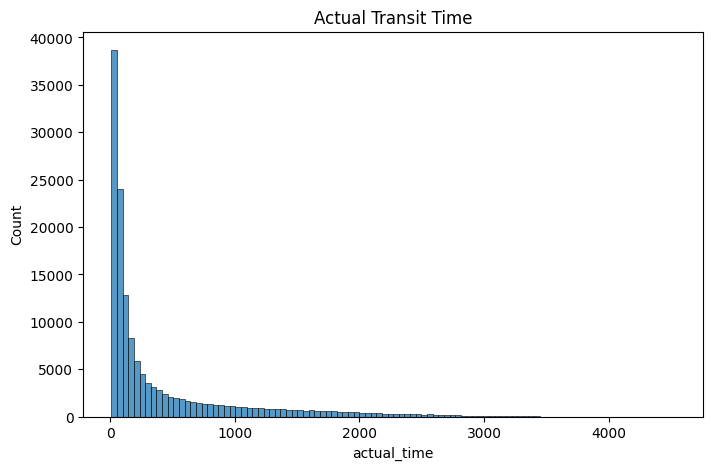

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["actual_time"],
    bins=100
)

plt.title("Actual Transit Time")
plt.show()

## OSRM Baseline

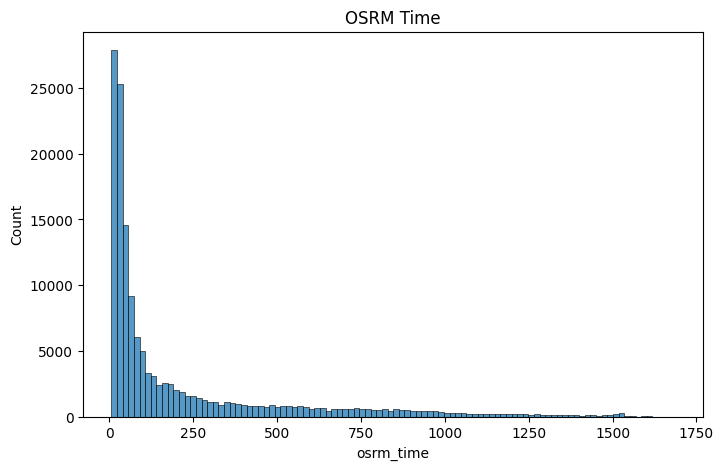

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["osrm_time"],
    bins=100
)

plt.title("OSRM Time")
plt.show()

## Delay Ratio

In [27]:
df["delay_ratio"] = (
    df["actual_time"] /
    df["osrm_time"]
)

df["delay_ratio"].describe()

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: delay_ratio, dtype: float64

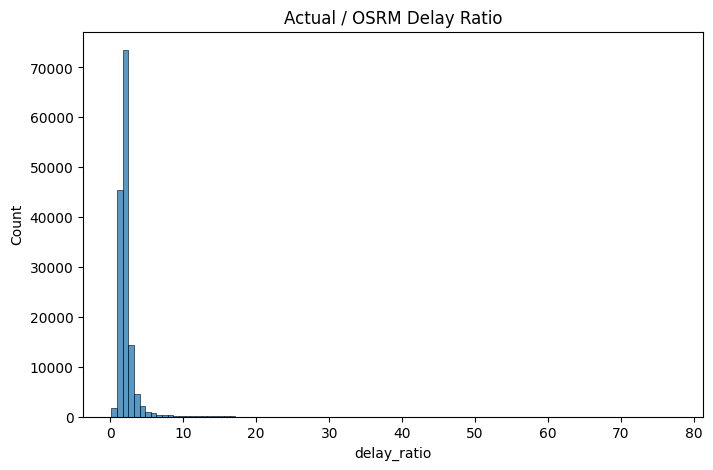

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["delay_ratio"],
    bins=100
)

plt.title("Actual / OSRM Delay Ratio")
plt.show()

## SLA Breach Rate

In [29]:
sla_rate = (
    (
        df["actual_time"]
        >
        1.2 * df["osrm_time"]
    ).mean()
    * 100
)

print(f"SLA Breach Rate: {sla_rate:.2f}%")

SLA Breach Rate: 94.50%


## Key Findings

- Large logistics network with multi-hop shipments.
- Significant deviation exists between actual and OSRM times.
- Frequent SLA breaches justify graph-based ETA modeling.

In [30]:
missing[missing > 0]

source_name         293
destination_name    261
dtype: int64

In [31]:
df["route_type"].value_counts()

route_type
FTL        99660
Carting    45207
Name: count, dtype: int64

In [32]:
print("Unique Trips:", df["trip_uuid"].nunique())
print("Unique Sources:", df["source_center"].nunique())
print("Unique Destinations:", df["destination_center"].nunique())

Unique Trips: 14817
Unique Sources: 1508
Unique Destinations: 1481


In [33]:
df["delay_ratio"].describe()

count    144867.000000
mean          2.120107
std           1.715421
min           0.144000
25%           1.604264
50%           1.857143
75%           2.213483
max          77.387097
Name: delay_ratio, dtype: float64

In [34]:
print(f"SLA Breach Rate: {sla_rate:.2f}%")

SLA Breach Rate: 94.50%


### Note

The SLA breach rate above is calculated on raw checkpoint-level records.

Since each trip appears across multiple segments, this value overestimates the true network-level breach rate.

A corrected SLA metric will be computed after OD-level aggregation in the next notebook.